# Energy Load Profile Classification with CNN

`pip install -r requirements.txt`

## 0. Setup

In [22]:
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader


In [23]:

from src.torch_cnn_2d import CLASS_NAMES
from src.torch_cnn_2d.data import (
    LoadProfileDataset, class_counts, fit_normalization, load_records, split_profiles
)
from src.torch_cnn_2d.model import SmallLoadProfileCNN
from src.torch_cnn_2d.engine import (
    calibrate_peak_bias, evaluate, predict_one, summarize_test, train_model
)
from src.torch_cnn_2d.plots import (
    plot_confusion_matrix, plot_dataset_preview,
    plot_learning_curves, plot_test_examples
)
from src.torch_cnn_2d.artifacts import save_run

In [24]:

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 1e-3

DATA_DIR = Path("dataset/load_energy_3class_daily")
OUTPUT_DIR = Path("outputs/cnn_load_profile_modular")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [25]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.14.1 | Device: mps


## 1. Load data

In [26]:
records, hourly, reference = load_records(DATA_DIR)
print("Total profiles:", len(records))
print("Buildings:", len({row["building_id"] for row in records}))
for name, count in class_counts(records).items():
    print(f"{name:14s}: {count}")

Total profiles: 6720
Buildings: 20
low activity  : 967
typical       : 4709
peak dominant : 1044


## 2. Preview the data

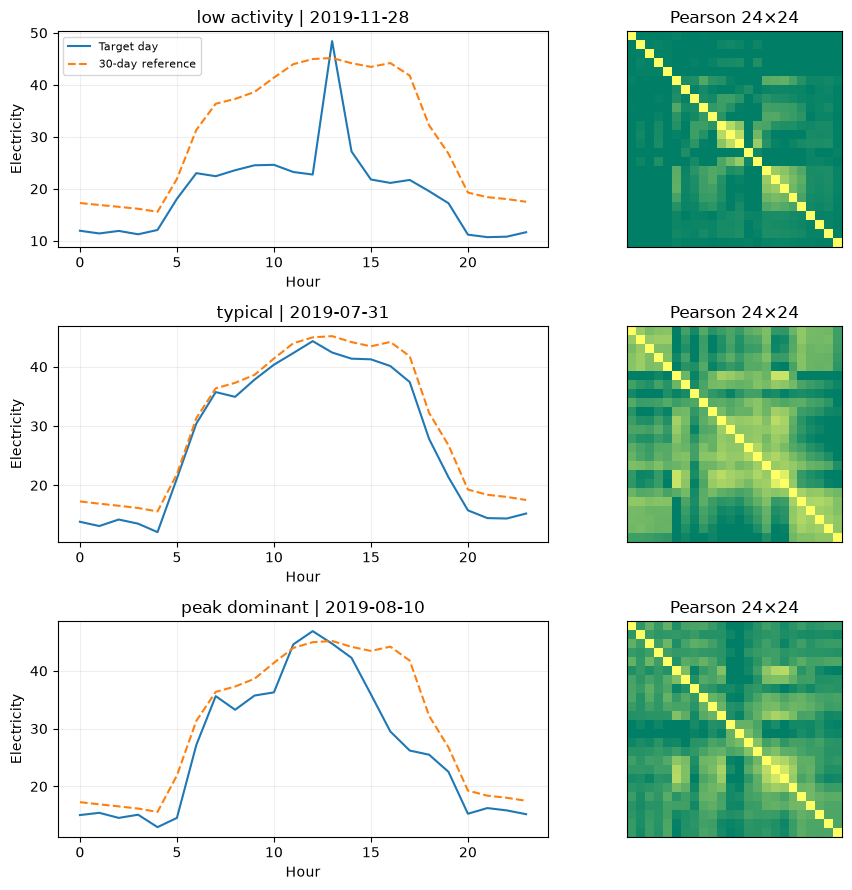

In [27]:
fig = plot_dataset_preview(
    records, hourly, reference, DATA_DIR, OUTPUT_DIR / "dataset_preview.png"
)
plt.show()

## 3. Split the data

Stratified by profile: 60% training, 20% validation, 20% test. Normalization uses training data only. Profiles from the same building may appear in different splits.

In [28]:
train_rows, val_rows, test_rows = split_profiles(records, seed=SEED)
for name, rows in [("Train", train_rows), ("Validation", val_rows), ("Test", test_rows)]:
    print(f"{name:10s} {len(rows):4d} profiles | {class_counts(rows)}")

normalization = fit_normalization(
    train_rows, 
    hourly, 
    reference
)

train_dataset = LoadProfileDataset(
    DATA_DIR, 
    train_rows, 
    hourly, 
    reference, 
    normalization
)

val_dataset = LoadProfileDataset(
    DATA_DIR, 
    val_rows, 
    hourly, 
    reference, 
    normalization
)

test_dataset = LoadProfileDataset(
    DATA_DIR, 
    test_rows, 
    hourly, 
    reference, 
    normalization
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_image, sample_label = train_dataset[0]
print("Input shape:", tuple(sample_image.shape), "| Label:", CLASS_NAMES[int(sample_label)])

Train      4031 profiles | {'low activity': 580, 'typical': 2825, 'peak dominant': 626}
Validation 1344 profiles | {'low activity': 193, 'typical': 942, 'peak dominant': 209}
Test       1345 profiles | {'low activity': 194, 'typical': 942, 'peak dominant': 209}
Input shape: (3, 24, 24) | Label: typical


## 4. Build the architecture

In [29]:
model = SmallLoadProfileCNN().to(device)
counts = np.bincount([int(row["class_id"]) for row in train_rows], minlength=3)
class_weights = len(train_rows) / (len(CLASS_NAMES) * counts)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        class_weights, 
        dtype=torch.float32, 
        device=device
    )
)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=1e-4
)

print(model)
print("Parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.round(3))))

SmallLoadProfileCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=64, bia

## 5. Preview the architecture with VisualTorch

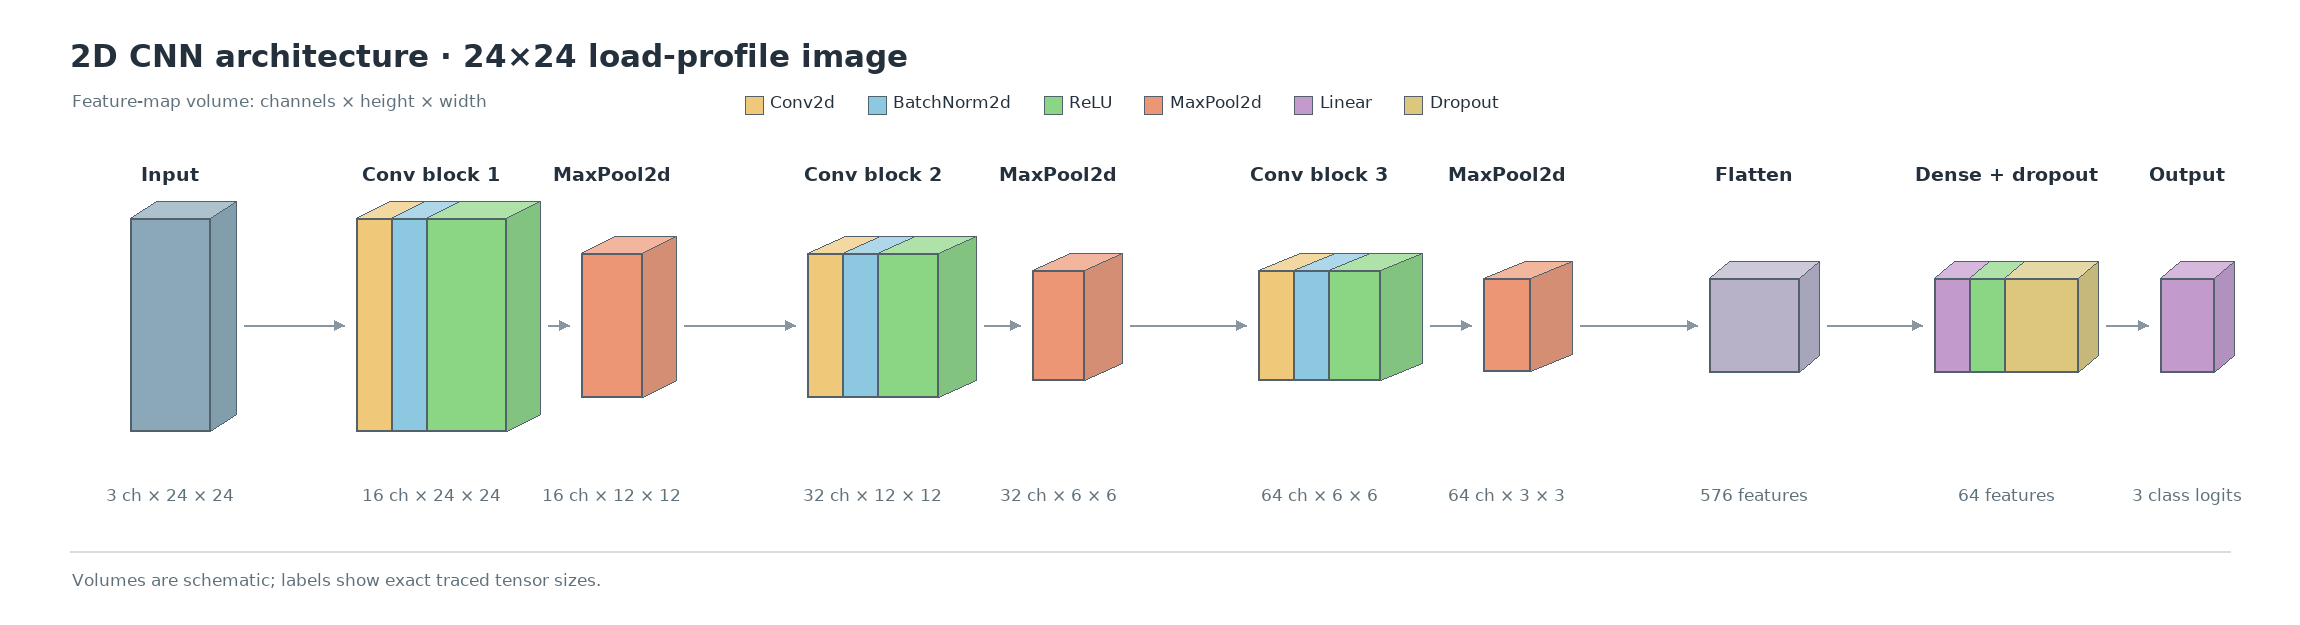

In [30]:
from importlib import reload
from src import architecture_volume

plot_architecture = reload(architecture_volume).plot_architecture
architecture_image = plot_architecture(model, (3, 24, 24), OUTPUT_DIR / "architecture.png")
display(architecture_image)

## 6. Train the model

The best epoch and peak-class decision bias are selected using validation data only.

In [31]:
%%time
print("Training ...")

history, best_epoch, best_val_f1 = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    device,
    max_epochs=MAX_EPOCHS, 
    patience=PATIENCE
)

Training ...
Epoch 01 | train loss 0.5515 | val loss 1.0289 | val macro-F1 0.579
Epoch 02 | train loss 0.3118 | val loss 0.2852 | val macro-F1 0.871
Epoch 03 | train loss 0.2390 | val loss 0.3120 | val macro-F1 0.833
Epoch 04 | train loss 0.2334 | val loss 0.2346 | val macro-F1 0.857
Epoch 05 | train loss 0.1848 | val loss 0.2483 | val macro-F1 0.861
Epoch 06 | train loss 0.1713 | val loss 0.2196 | val macro-F1 0.890
Epoch 07 | train loss 0.1537 | val loss 0.2403 | val macro-F1 0.895
Epoch 08 | train loss 0.1555 | val loss 0.1954 | val macro-F1 0.877
Epoch 09 | train loss 0.1490 | val loss 0.2445 | val macro-F1 0.860
Epoch 10 | train loss 0.1361 | val loss 0.2257 | val macro-F1 0.912
Epoch 11 | train loss 0.1392 | val loss 0.2127 | val macro-F1 0.910
Epoch 12 | train loss 0.1347 | val loss 0.1725 | val macro-F1 0.906
Epoch 13 | train loss 0.1165 | val loss 0.2395 | val macro-F1 0.916
Epoch 14 | train loss 0.1136 | val loss 0.1628 | val macro-F1 0.918
Epoch 15 | train loss 0.0982 | val 

In [32]:
decision_bias, calibrated_val_f1 = calibrate_peak_bias(model, val_loader, device)

print(f"Best epoch: {best_epoch}")
print(f"Validation macro-F1: {best_val_f1:.3f}")
print(f"Calibrated validation macro-F1: {calibrated_val_f1:.3f}")
print(f"Peak-class bias: {decision_bias[2]:.3f}")

Best epoch: 21
Validation macro-F1: 0.928
Calibrated validation macro-F1: 0.932
Peak-class bias: 0.300


## 7. Evaluate the model

In [33]:
test_result = evaluate(model, test_loader, criterion, device, decision_bias)
metrics = summarize_test(test_result, train_rows)

In [34]:
print(f"Test loss: {metrics['test_loss']:.4f}")
print(f"Test accuracy: {metrics['test_accuracy']:.3f}")
print(f"Test macro-F1: {metrics['test_macro_f1']:.3f}")
print(f"Majority-class baseline macro-F1: {metrics['majority_baseline_macro_f1']:.3f}")
print("\nPer-class scores:")
for name in CLASS_NAMES:
    score = metrics["per_class"][name]
    print(f"{name:14s} precision={score['precision']:.3f} "
          f"recall={score['recall']:.3f} F1={score['f1']:.3f} n={score['support']}")


print("\nPrediction examples:")
for class_id in range(len(CLASS_NAMES)):
    index = next(i for i, row in enumerate(test_rows) if int(row["class_id"]) == class_id)
    print(test_rows[index]["sample_id"], "| actual:", CLASS_NAMES[class_id],
          "| predicted:", CLASS_NAMES[int(test_result["predicted"][index])])

Test loss: 0.2208
Test accuracy: 0.949
Test macro-F1: 0.924
Majority-class baseline macro-F1: 0.275

Per-class scores:
low activity   precision=0.908 recall=0.964 F1=0.935 n=194
typical        precision=0.974 recall=0.967 F1=0.971 n=942
peak dominant  precision=0.877 recall=0.856 F1=0.867 n=209

Prediction examples:
BN024_2020-02-09 | actual: low activity | predicted: low activity
BN024_2019-11-18 | actual: typical | predicted: typical
BN077_2019-10-30 | actual: peak dominant | predicted: peak dominant


## 8. Test predictions visually

Green titles are correct predictions; red titles are errors.

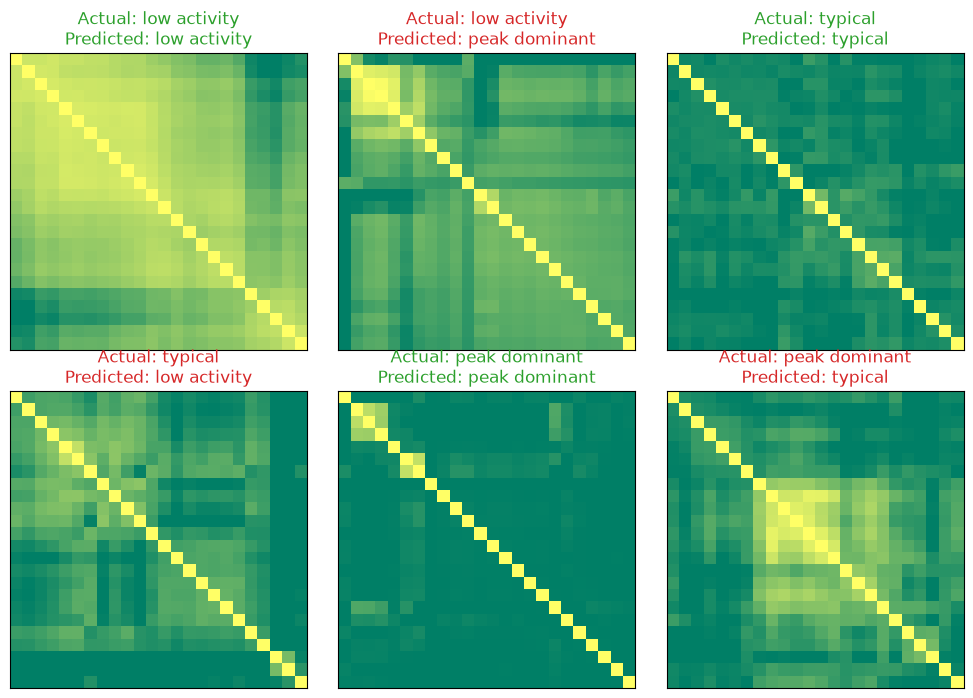

In [35]:
fig = plot_test_examples(
    test_rows, test_result["predicted"], DATA_DIR, OUTPUT_DIR / "test_examples.png"
)
plt.show()

In [36]:
actual, predicted, probabilities = predict_one(
    model, 
    test_dataset, 
    index=0, 
    device=device, 
    decision_bias=decision_bias
)

print("Test sample:", test_rows[0]["sample_id"])

print("Actual:", CLASS_NAMES[actual], "| Predicted:", CLASS_NAMES[predicted])

print("Probabilities:", dict(zip(CLASS_NAMES, probabilities.round(3))))

Test sample: BN024_2019-11-18
Actual: typical | Predicted: typical
Probabilities: {'low activity': np.float32(0.001), 'typical': np.float32(0.999), 'peak dominant': np.float32(0.0)}


## 9. Compare performance

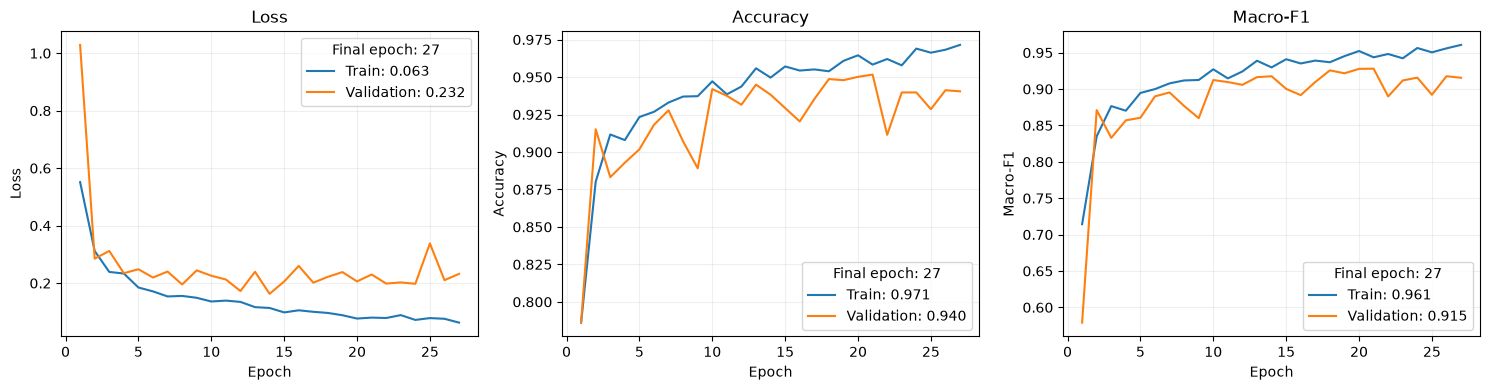

In [37]:
fig = plot_learning_curves(history, OUTPUT_DIR / "training_curves.png")
plt.show()

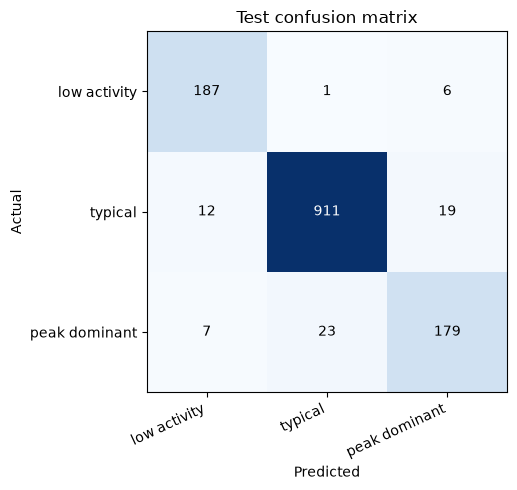

In [38]:
fig = plot_confusion_matrix(test_result["matrix"], OUTPUT_DIR / "confusion_matrix.png")
plt.show()

## 10. Save the results

In [39]:
report = save_run(
    OUTPUT_DIR, model, history, metrics,
    (train_rows, val_rows, test_rows), normalization,
    decision_bias, SEED, best_epoch, best_val_f1, calibrated_val_f1
)
print("Saved to:", OUTPUT_DIR.resolve())
print("Test accuracy:", round(report["test_accuracy"], 3),
      "| Test macro-F1:", round(report["test_macro_f1"], 3))

Saved to: /Users/zendi.iklima/Documents/UTP/My Lectures/Intelligence System/Scripts/outputs/cnn_load_profile_modular
Test accuracy: 0.949 | Test macro-F1: 0.924
